<a href="https://colab.research.google.com/github/A1phar1u5/2026_StatPrak/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Онлайн ритейл - анализ пользователей и их заказов

Авторы проекта: **Медведев Пётр** и **Октысюк Ксения**

Ссылка на датасет: https://www.kaggle.com/datasets/ertugrulesol/online-retail-data/data

## Описание проекта / Декомпозиция задачи

### Цель исследования

Определить основные категории клиентов сервиса и построить модель регрессии для цены заказа.


### Описание датасета

Датасет содержит данные о клиентах сервиса онлайн ритейла и их заказах.
Колонки:
- ***customer_id*** — идентификатор пользователя,
- ***order_date*** — дата заказа,
- ***product_id*** — идентификатор товара,
- ***category_id*** — идентифактор категории товара,
- ***category_name*** — название категории товара,
- ***product_name*** — количество баллов собственности,
- ***quantity*** — количество заказанного товара,
- ***price*** — цена за единицу товара,
- ***payment_method*** — способ оплаты,
- ***city*** — город,
- ***review_score*** — оценка товара,
- ***gender*** — пол,
- ***age*** — возраст.


###  Задачи исследования

- 1) Загрузка и описание данных:
    - подключение библиотек;
    - загрузка данных;
    - первичный осмотр данных;
    - промежуточный вывод по первому знакомству с данными;

- 2) Предобработка данных:
    - классификация пропусков (анализ их природы и соответствующая обработка);
    - поиск явных и неявных дубликатов и их обработка;
    - приведение столбцов с неправильными типами данных к соответствующему типу, если таковые имеются;
    - промежуточный вывод по предобработке;

- 3) Исследовательский анализ данных ***EDA***:
    - Анализ покупателей и заказов:
        - Распределение клиентов по демографическим признакам (пол и возраст);
        - Распределение заказов по дням недели;
        - Сравнить средний чек и частоту покупок между;
        - Предпочтения возрастных групп по дням недели;
        - Распределение заказов по месяцам;
    - Анализ выручки:
        - Топ-10 товаров по выручке и по количеству проданных единиц;
        - Распределение выручки по категориям товаров;
        - Топ-10 городов по выручке и среднему чеку;
        - Категории товаров в городах с самой большой выручкой;
        - Доли от всей выручки по городам;
        - Распределение сумм заказов по способам оплаты;
        - Анализ способов оплаты;
  - Анализ оценок:
      - Средние оценки по способам оплаты;
      - Распределение оценок;
      - Распределение цен по оценкам;
      - Средние оценки по категориям;
      - Доли низких оценок по категориям;

- 5) Задача построения модели регрессии для количества товара в заказе;


- 6) Задача кластеризации пользователей:
      - По полу, возрасту и месяцу покупки;
      - По полу, возрасту и общей цене заказа;
      - По полу, возрасту и оценке;


- 7) Выводы

## Загрузка библиотек и данных, первичный осмотр данных

In [1]:
#Подключение библиотек
import kagglehub
import os

import pandas as pd
import numpy as np
import seaborn as sns
import random

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


#Регрессия
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


#Кластеризация
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

In [2]:
#Загрузка данных из файлов
path = kagglehub.dataset_download("ertugrulesol/online-retail-data")
df = pd.read_csv(os.path.join(path, "synthetic_online_retail_data.csv"), encoding = "latin-1")

#Зададим правила вывода
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

#Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Using Colab cache for faster access to the 'online-retail-data' dataset.


In [3]:
#Функция для получения предварительной информации о данных
def data_info(data):
    #Получение предварительной информации о данных из датасета через метод info
    data.info()

    #Расчет доли пропущенных значений в каждом из столбцов датасета
    print()
    print('Доля пропущенных значений:')
    mis_values_visit = data.isnull().sum().to_frame('missing_values')
    mis_values_visit['Доля'] = round(data.isna().mean(),2)
    print(mis_values_visit.sort_values(by='Доля', ascending=False))
    print()

    #Получение предварительной информации о данных через отображение первых строк датасета
    display(data.head())

In [4]:
#Получение предварительной информации о данных flights
data_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1000 non-null   int64  
 1   order_date      1000 non-null   object 
 2   product_id      1000 non-null   int64  
 3   category_id     1000 non-null   int64  
 4   category_name   1000 non-null   object 
 5   product_name    1000 non-null   object 
 6   quantity        1000 non-null   int64  
 7   price           1000 non-null   float64
 8   payment_method  1000 non-null   object 
 9   city            1000 non-null   object 
 10  review_score    799 non-null    float64
 11  gender          897 non-null    object 
 12  age             1000 non-null   int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB

Доля пропущенных значений:
                missing_values  Доля
review_score               201  0.20
gender                     103  0.10
product_id      

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.00,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,NaN,M,59
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.00,F,64
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.00,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.00,F,33


### Промежуточный вывод по исходному состоянию данных
На текущем этапе работы с данными можно заметить следующее:
    
- В данных есть пропуски в столбах 'gender'(20% значений) и 'review_score' (10% значений);


- Тип данных столбца 'order_date' не соответствует содержащимся в нём данным, требуется привести его к типу 'datetime';


- Судя по всему данные хорошего качества, но стоит проверить их на наличие дубликатов.

## Предобработка данных

### Обработка пропусков

Так как в столбце 'gender' 20% значений пропущены, то заполнение пропусков модой или медианой сильно повлияет на результаты исследования. Поэтому заполнены индикаторным значением 'Unknown':

In [5]:
df['gender'] = df['gender'].fillna('Unknown')

Теперь заполним пропуски в столбце 'review_score'. Чтобы уменьшить возможные искажения результатов заполним пропущенные значения по категориям соответствующими медианами:

In [6]:
df['review_score'] = df['review_score'].fillna(
    df.groupby('category_name')['review_score'].transform('median')
)

### Поиск дубликатов

Для начала проверим данные на наличие явных дубликатов:

In [7]:
#Функция для подсчёта дубликатов
def data_duplicates_sum(data, name):
    if data.duplicated().sum() > 0:
        print(f'Количество дубликатов в таблице {name}: {data.duplicated().sum()}')
    else:
        print(f'В таблице {name} явных дубликатов нет')

In [8]:
#Проверка на наличие явных дубликатов в датафрейме
data_duplicates_sum(data=df, name='df')

В таблице df явных дубликатов нет


Теперь проверим столбцы 'category_name', 'product_name', 'gender' и 'payment_method' на наличие неявных дубликатов:

In [9]:
#Проверка на наличие неявных дубликатов в столбцах 'category_name', 'gender' и 'payment_method'
print('Уникальные значения в столбце category_name:', df['category_name'].unique())
print('Уникальные значения в столбце product_name:', df['product_name'].unique())
print('Уникальные значения в столбце gender:', df['gender'].unique())
print('Уникальные значения в столбце payment_method:', df['payment_method'].unique())

Уникальные значения в столбце category_name: ['Electronics' 'Sports & Outdoors' 'Books & Stationery' 'Fashion'
 'Home & Living']
Уникальные значения в столбце product_name: ['Smartphone' 'Soccer Ball' 'Tent' 'Story Book' 'Skirt' 'Tablet'
 'Yoga Mat' 'Pillow' 'Blanket' 'Smartwatch' 'Notebook' 'Laptop' 'Pen'
 'Shirt' 'Carpet' 'Novel' 'Eraser' 'Vase' 'Dress' 'Pants' 'T-shirt'
 'Running Shoes' 'Basketball' 'Painting' 'Headphones']
Уникальные значения в столбце gender: ['F' 'M' 'Unknown']
Уникальные значения в столбце payment_method: ['Credit Card' 'Bank Transfer' 'Cash on Delivery']


Проверим столбец 'city' на неявные дубликаты:

In [10]:
#Проверка на наличие неявных дубликатов в столбце 'city'
print('Старое количество уникальных наименований:',len(df['city'].unique()))
print('Новое количество уникальных наименований:',len(df['city'].str.lower().str.replace(' ', '').unique()))

Старое количество уникальных наименований: 962
Новое количество уникальных наименований: 962


### Приведение столбцов к нужному типу

Приведём столбец 'order_date' к типу 'datetime':

In [11]:
df['order_date'] = pd.to_datetime(df['order_date'])

###  Промежуточный вывод после предобработки
На текущем этапе работы с данными можно заметить следующее:
- Пропуски в столбцах 'gender' и 'review_score' скорее всего возникли из-за того, что клиенты просто не указывали свой пол.

- Так как в этом столбце были пропущены 20% значений, то для того, чтобы избежать серьёзных искажений результатов, пропуски были заполнены индикаторным значением 'Unknown';

- Пропуски в столбце 'review_score' составляли 10% значений, они были заполнены медианными значениями по категориями товаров, чтобы уменьшить возможные искажения результатов;

- В данных не было явных дубликатов;

- Столбцы 'city', 'category_name', 'product_name', 'gender', и 'payment_method' были проверены на наличие неявных дубликатов, в данных их не оказалось;

- Столбец 'order_date' был приведен к соответствующему типу данных datetime.

## Исследование данных(EDA)

In [12]:
#Сохраняем копию исходного датасета
df_original = df.copy()

### Анализ клиентов и заказов

#### Распределение клиентов по демографическим признакам

In [13]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Распределение возрастов', 'Распределение по полу'))

#Гистограмма возрастов
fig.add_trace(go.Histogram(x=df['age'], nbinsx=15, name='Age', marker_color='lightblue'), row=1, col=1)

#Столбчатая диаграмма для пола
gender_counts = df['gender'].value_counts(dropna=False).reset_index()
gender_counts.columns = ['gender', 'count']
fig.add_trace(go.Bar(x=gender_counts['gender'], y=gender_counts['count'],
                      marker_color='salmon', name='Gender'), row=1, col=2)

fig.update_layout(height=500, width=1000, title_text='Демографические признаки', showlegend=False)
fig.show()

##### Промежуточные выводы по демографическим признакам
По данным графикам можно сделать следующие выводы:

- Клиенты в целом равномерно распределены по возрасту за исключением двух возрастных групп: 15-19 и 75-79. Лидируют по количеству клиентов группы 60-64(104 человека) и 25-29(94 человека);

- Клиенты равномерно распределены по полу.

#### Распределение заказов по дням недели

In [14]:
#Извлекаем день недели и месяц
df['day_of_week'] = df['order_date'].dt.day_name()
df['month'] = df['order_date'].dt.month_name()

In [15]:
#Столбчатая диаграмма по дням недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = df['day_of_week'].value_counts().reindex(day_order).reset_index()
orders_by_day.columns = ['day', 'count']

fig = px.bar(orders_by_day, x='day', y='count',
              title='Количество заказов по дням недели',
              labels={'day': 'День недели', 'count': 'Количество заказов'},
              color='count', color_continuous_scale='Sunset',
              text='count')
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.show()

##### Промежуточные выводы по распределению заказов по дням недели
По данным графикам можно сделать следующие выводы:

- В целом заказы распределены по дням недели равномерно, но видно, что в будни их больше;

- Больше всего заказов в пятницу (150), меньше всего в воскресенье (130).

#### Предпочтения возрастных групп по дням недели

In [16]:
#Создаём столбец с возрастными группами
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 60, 76],
                          labels=['18-30', '31-45', '46-60', '60+'])

#Создаём сводную таблицу
day_age_crosstab = pd.crosstab(df['age_group'], df['day_of_week'], normalize='index') * 100
day_age_crosstab = day_age_crosstab[day_order]

In [17]:
#Тепловая карта для дней недели по возрастным группам
fig = px.imshow(day_age_crosstab.round(1),
                text_auto='.1f',
                aspect='auto',
                title='Предпочтения возрастных групп по дням недели',
                labels=dict(x='День', y='Возрастная группа', color='Процент (%)'),
                color_continuous_scale='Blues')
fig.update_layout(height=400, width=700)
fig.show()

##### Промежуточные выводы по предпочтениям возрастных групп по дням недели
По данным графикам можно сделать следующие выводы:

- Для группы 18-30 самыми популярными днями были четверг (16.4%), вторник (15.5%) и воскресенье (15.5%);

- Для группы 31-45 самыми популярными днями были четверг (17.0%), понедельник (15.4%) и пятница (15.1%);

- Для группы 46-60 самыми популярными днями были среда (16.8%) и пятница (16.0%);

- Для группы 60+ самыми популярными днями были вторник (19.2%) и суббота (16.2%).

#### Распределение заказов по месяцам

In [18]:
#Сводная таблица
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
orders_by_month = df['month'].value_counts().reindex(months_order).reset_index()
orders_by_month.columns = ['month', 'count']

In [19]:
#График количества заказов по месяцам
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
orders_by_month = df['month'].value_counts().reindex(months_order).reset_index()
orders_by_month.columns = ['month', 'count']

fig = px.line(orders_by_month, x='month', y='count', markers=True,
              title='Количество заказов по месяцам',
              labels={'month': 'Месяц', 'count': 'Количество заказов'})
fig.update_layout(height=500, width=800)
fig.show()

##### Промежуточные выводы по распределению заказов по месяцам
По данным графикам можно сделать следующие выводы:

- Наибольшее количество заказов было сделано в декабре и январе, в мае и в период с июля по сентябрь;

- Для группы 31-45 самыми популярными днями были четверг (17.0%), понедельник (15.4%) и пятница (15.1%);

- Для группы 46-60 самыми популярными днями были среда (16.8%) и пятница (16.0%);

- Для группы 60+ самыми популярными днями были вторник (19.2%) и суббота (16.2%).

### Анализ выручки

#### Топ-10 товаров по выручке и по количеству проданных единиц

In [20]:
#Создаём total_price с общей ценой заказа
df['total_price'] = df['quantity'] * df['price']

In [21]:
#Топ-10 продуктов по выручке и количеству
top_revenue = df.groupby('product_name')['total_price'].sum().nlargest(10).reset_index()
top_quantity = df.groupby('product_name')['quantity'].sum().nlargest(10).reset_index()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Топ-10 товаров по выручке', 'Топ-10 товаров по количеству'))

fig.add_trace(go.Bar(x=top_revenue['total_price'], y=top_revenue['product_name'],
                      orientation='h', marker_color='lightgreen', name='Revenue'), row=1, col=1)
fig.add_trace(go.Bar(x=top_quantity['quantity'], y=top_quantity['product_name'],
                      orientation='h', marker_color='skyblue', name='Quantity'), row=1, col=2)

fig.update_layout(height=600, width=1200, showlegend=False)
fig.show()

##### Промежуточные выводы по топ-10 товарам по выручке и количеству проданных единиц
По данным графикам можно сделать следующие выводы:

- Смартфоны лидируют и по выручке, и по количеству проданного товара, также следует отметить маты для йоги и футбольные мячи;

- Товары из категории ***"Электроника"*** заняли 5 позиций в топе по выручке (смартфоны, планшеты, ноутбуки, умные часы и наушники), из категории ***"Спорт"*** - 2 позиции (маты для йоги и футбольные мячи), из категории ***"Книги"*** - 1 позиция (тетради), из категории ***"Вещи для дома"*** - 1 позиция (вазы), из категории ***"Одежда"*** - 1 позиция (футболки);

- Товары из категории ***"Электроника"*** заняли 3 позиций в топе по количеству (смартфоны, ноутбуки и наушники), из категории ***"Спорт"*** - 3 позиции (маты для йоги, футбольные мячи и  ботинки для бега), из категории ***"Книги"*** - 2 позиции (тетради и ластики), из категории ***"Одежда"*** - 1 позиция (футболки), из категории ***"Вещи для дома"*** - 1 позиция (вазы).

#### Распределение выручки по категориям товаров

In [22]:
#Сводная таблица по выручке категорий
cat_stats = df.groupby('category_name').agg({
    'total_price': 'sum'
}).round(2).reset_index().sort_values(by='total_price', ascending=False)


In [23]:
#Столбчатая диаграмма для выручки по категориям
fig = px.bar(cat_stats, x='category_name', y='total_price', title='Выручка по категориям',
               color='total_price', color_continuous_scale='Reds', text='total_price',
               labels={'total_price': 'Общая выручка', 'category_name': 'Категория товаров'})
fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig.show()

##### Промежуточный вывод по распределению выручки товаров по категориям
По данному графику можно сделать следующий вывод:

- Лидером является категория "Электроника", на втором месте - "Спорт", на третьем - "Книги".

#### Топ-10 городов по выручке и среднему чеку

In [24]:
#Сводные таблицы
city_revenue = df.groupby('city')['total_price'].sum().nlargest(10).reset_index()
city_avg_order = df.groupby('city')['total_price'].mean().nlargest(10).reset_index()

In [25]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Топ-10 городов по выручке', 'Топ-10 городов по среднему чеку'))

#Топ-10 городов по выручке
fig.add_trace(go.Bar(x=city_revenue['city'], y=city_revenue['total_price'],
                      marker_color='coral', name='Revenue'), row=1, col=1)

#Топ-10 городов по среднему чеку
fig.add_trace(go.Bar(x=city_avg_order['city'], y=city_avg_order['total_price'],
                      marker_color='teal', name='Avg Order'), row=1, col=2)

fig.update_layout(height=500, width=1200, showlegend=False)
fig.update_xaxes(tickangle=45)
fig.show()

##### Промежуточный вывод по распределению выручки по городам
По данным графикам можно сделать следующий вывод:

- Видно, что города на этих двух графиках не совпадают, из чего мы можем сделать вывод о то, что в городах с самой большой выручкой средний чек меньше, но там делают больше покупок.

#### Категории товаров в городах с самой большой выручкой

In [26]:
#Сводная таблица
city_cat_all = df.pivot_table(
    index='city',
    columns='category_name',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

In [27]:
#Топ-10 городов по общей выручке с тепловой картой по категориям
top10_cities = df.groupby('city')['total_price'].sum().nlargest(10).index
city_cat_top10 = city_cat_all.loc[top10_cities]

fig = px.imshow(city_cat_top10,
                text_auto='.0f',
                aspect='auto',
                title='Тепловая карта по выручке: Топ-10 городов и категории',
                labels=dict(x='Категория', y='Город', color='Выручка'),
                color_continuous_scale='YlOrRd',
                height=600)
fig.show()

##### Промежуточный вывод по тепловой карте
По данному графику можно сделать следующие выводы:

- Port Melissaborough лидирует в категории "Вещи для дома", Patriciaville - в категории "Спорт", Johnsonborough - в категории "Одежда", East David - в категории "Электроника", East William - в категории "Книги";

- Больше всего выручки в этих городах было получено от категории "Вещи для дома", меньше всего - от категории "Электроника".

#### Доли от всей выручки по городам

In [28]:
#Сводная таблица
top5_revenue = city_revenue.copy()
top5_revenue.loc[5] = ['Другие', city_revenue['total_price'].sum() - top5_revenue['total_price'].head(5).sum()]
top5_revenue = top5_revenue.head(6)

In [29]:
#Круговая диаграмма выручки по топ-5 городам
fig = px.pie(top5_revenue, values='total_price', names='city',
              title='Распределение выручки',
              color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

##### Промежуточный вывод по долям выручки по городам
По данному графику можно сделать следующий вывод:

- На 5 городов с самой большой выручкой приходится более половина от общей выручки на платформе.

#### Распределение сумм заказов по способам оплаты

In [30]:
#Boxplot с распределением сумм заказов по методам оплаты
fig = px.box(df, x='payment_method', y='total_price', color='payment_method',
              title='Распределение сумм заказов по способам оплаты',
              labels={'payment_method': 'Способ оплаты', 'total_price': 'Стоимость заказов'},
              color_discrete_sequence=px.colors.qualitative.Set2)
fig.show()

##### Промежуточный вывод по распределению сумм заказов по способам оплаты
По данному графику можно сделать следующие выводы:

- В целом у всех трёх способов оплаты наблюдается схожая ситуация: медианы, 1-ая и 3-ая квартили близки по своим значениям;

- Видно, что для заказов, оплаченных банковскими переводами верхняя граница ниже чем у двух других способов оплаты, и из-за этого чуть больше значений-выбросов.

#### Анализ способов оплаты

In [31]:
#Сводная таблица
pay_counts = df['payment_method'].value_counts().reset_index()
pay_counts.columns = ['payment_method', 'count']

pay_avg_order = df.groupby('payment_method')['total_price'].mean().reset_index()

In [32]:
fig = make_subplots(rows=1, cols=2,
                     subplot_titles=('Распределение способов оплаты', 'Средний чек по способом оплаты'),
                     specs=[[{'type': 'domain'}, {'type': 'xy'}]])

#Распределение заказов по способам оплаты
fig.add_trace(go.Pie(labels=pay_counts['payment_method'], values=pay_counts['count'],
                      hole=0.3, name='Share'), row=1, col=1)

#Средний чек по способам оплаты
fig.add_trace(go.Bar(x=pay_avg_order['payment_method'], y=pay_avg_order['total_price'],
                      marker_color='lightcoral', name='Avg Order'), row=1, col=2)

fig.update_layout(height=500, width=1100, title_text='Анализ способов оплаты', showlegend=False)
fig.show()

##### Промежуточный вывод по анализу способов оплаты
По данному графику можно сделать следующие выводы:

- Оплата наличными встречается немного чаще, но в целом все три способа оплаты одинаково популярны;

- Средний чек у заказов, оплаченных кредитными картами, чуть выше, чем  у остальных двух способов, но они не сильно различаются.

### Анализ оценок

#### Средние оценки по способам оплаты

In [33]:
#Сводная таблица
pay_review = df.groupby('payment_method')['review_score'].mean().reset_index()

In [34]:
#Столбчатая диаграмма со средними оценками по способам оплаты
fig = px.bar(pay_review, x='payment_method', y='review_score',
              title='Средние оценки по способам оплаты',
              labels={'payment_method': 'Способ оплаты', 'review_score': 'Оценка'},
              color='review_score', color_continuous_scale='Viridis',
              text='review_score')
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(yaxis_range=[1, 5])
fig.show()

##### Промежуточный вывод по средним оценкам по способам оплаты
По данному графику можно сделать следующий вывод:

- Средние оценки для способов оплаты практически не отличаются.

#### Распределение оценок

In [35]:
#Сводная таблица
review_counts = df['review_score'].value_counts(dropna=False).sort_index().reset_index()
review_counts.columns = ['review_score', 'count']


In [36]:
#Столбчатая диаграмма с распределением оценок
fig = px.bar(review_counts, x='review_score', y='count',
              title='Распределение оценок',
              labels={'review_score': 'Оценка', 'count': 'Количество'},
              color='count', color_continuous_scale='Aggrnyl',
              text='count')
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.show()

##### Промежуточный вывод по распределению оценок
По данному графику можно сделать следующий вывод:

- Более 75% всех заказов имеют хорошую оценку 4 или 5 (781 заказ), количество заказов с плохим оценками 1 и 2 сильно меньше (110 заказов).

#### Распределение цен по оценкам

In [37]:
#Boxplot с распределением цен по оценкам
fig = go.Figure()

for score in sorted(df['review_score'].unique()):
    subset = df[df['review_score'] == score]['price']
    fig.add_trace(go.Box(y=subset, name=f'Score {score}', boxmean='sd'))

fig.update_layout(title='Распределение цен по оценкам',
                   xaxis_title='Оценка',
                   yaxis_title='Цена единицы товара',
                   height=500,
                   width=700)
fig.show()


##### Промежуточный вывод по распределению оценок
По данному графику можно сделать следующие выводы:

- Для всех 5 оценок нет значений-выбросов;

- По графикам для оценок "1", "4", "5" видно, что у них различаются квартили, межквартильный размах, верхние и нижние границы, но при этом на каждом из трёх графиков медиана совпадает со средним;

- На графике для оценки "2" видно, что медиана меньше среднего, что говорит о наличии смещения цен в большую сторону в этой группе;

- График для оценки "3" обладает самым большим межквартильным размахом, а также видно, что медиана больше среднего, что говорит о наличии смещения цен в меньшую сторону в этой группе.

#### Средние оценки по категориям

In [38]:
#Сводная таблица
avg_review_cat = df.groupby('category_name')['review_score'].mean().round(2).reset_index()

In [39]:
#Столбчатая диаграмма со средними оценками по категориям
fig = px.bar(avg_review_cat, x='category_name', y='review_score',
              title='Средние оценки по категориям',
              labels={'review_score': 'Оценка', 'category_name': 'Категория'},
              color='review_score', color_continuous_scale='RdYlGn',
              range_color=[1, 5], text='review_score')
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(yaxis_range=[1, 5])
fig.show()

##### Промежуточный вывод по средним оценкам по категоряим
По данному графику можно сделать следующий вывод:

- У категории товаров "Спорт" средняя оценка заметно выше, чем у других, остальные 4 категории между собой практически не различаются.

#### Доли низких оценок по категориям

In [40]:
#Сводная таблица
low_review_pct = df.groupby('category_name').apply(
    lambda x: (x['review_score'].between(1, 2).sum() / x['review_score'].notna().sum()) * 100
).round(1).reset_index(name='low_score_percentage').sort_values(by='low_score_percentage', ascending=False)

/tmp/ipykernel_105361/1057728142.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [41]:
#Столбчатая диаграмма с долями низких оценок (1-2) по категориям
fig = px.bar(low_review_pct, x='category_name', y='low_score_percentage',
              title='Доля низких оценок ("1" и "2") по категориям',
              labels={'low_score_percentage': 'Доля низких оценок', 'category_name': 'Категория'},
              color='low_score_percentage', color_continuous_scale='Reds',
              text='low_score_percentage')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.show()

##### Промежуточный вывод по долям низких оценок по категоряим
По данному графику можно сделать следующий вывод:

- У категории "Вещи для дома" самая высокая доля низких оценок(13.1%), на втором месте категория "Спорт"(11.8%), остальные 3 категории между собой практически не различаются.

### Итоговый вывод по EDA

По итогам проведенного исследовательского анализа данных можно сказать следующее:


 1) Клиенты и заказы:
 - Клиенты в целом равномерно распределены по возрасту за исключением двух возрастных групп: 15-19 и 75-79. Лидируют по количеству клиентов группы 60-64(104 человека) и 25-29(94 человека);

 - Клиенты равномерно распределены по полу;

 - В целом заказы распределены по дням недели равномерно, но в будни их больше;

 - Больше всего заказов в пятницу (150), меньше всего в воскресенье (130);

 - Для возрастной группы 18-30 самыми популярными днями были четверг (16.4%), вторник (15.5%) и воскресенье (15.5%);

 - Для возрастной группы 31-45 самыми популярными днями были четверг (17.0%), понедельник (15.4%) и пятница (15.1%);

 - Для возрастной группы 46-60 самыми популярными днями были среда (16.8%) и пятница (16.0%);

 - Для возрастной группы 60+ самыми популярными днями были вторник (19.2%) и суббота (16.2%);

 - Наибольшее количество заказов было сделано в декабре и январе, в мае и в период с июля по сентябрь;

 - Для группы 31-45 самыми популярными днями были четверг (17.0%), понедельник (15.4%) и пятница (15.1%);

 - Для группы 46-60 самыми популярными днями были среда (16.8%) и пятница (16.0%);

 - Для группы 60+ самыми популярными днями были вторник (19.2%) и суббота (16.2%).

2) Выручка:
 - Смартфоны лидируют и по выручке, и по количеству проданного товара, также следует отметить маты для йоги и футбольные мячи;

 - Товары из категории ***"Электроника"*** заняли 5 позиций в топе по выручке (смартфоны, планшеты, ноутбуки, умные часы и наушники), из категории ***"Спорт"*** - 2 позиции (маты для йоги и футбольные мячи), из категории ***"Книги"*** - 1 позиция (тетради), из категории ***"Вещи для дома"*** - 1 позиция (вазы), из категории ***"Одежда"*** - 1 позиция (футболки);

 - Товары из категории ***"Электроника"*** заняли 3 позиций в топе по количеству (смартфоны, ноутбуки и наушники), из категории ***"Спорт"*** - 3 позиции (маты для йоги, футбольные мячи и  ботинки для бега), из категории ***"Книги"*** - 2 позиции (тетради и ластики), из категории ***"Одежда"*** - 1 позиция (футболки), из категории ***"Вещи для дома"*** - 1 позиция (вазы);

 - Лидером является категория "Электроника", на втором месте - "Спорт", на третьем - "Книги";

 - В городах с самой большой выручкой средний чек меньше, но там делают больше покупок;

 - Среди топ-10 городов по выручке Port Melissaborough лидирует в категории "Вещи для дома", Patriciaville - в категории "Спорт", Johnsonborough - в категории "Одежда", East David - в категории "Электроника", East William - в категории "Книги";

 - Больше всего выручки в этих городах было получено от категории "Вещи для дома", меньше всего - от категории "Электроника";

 - На 5 городов с самой большой выручкой приходится более половина от общей выручки на платформе;

 - В целом у всех трёх способов оплаты наблюдается схожая ситуация с суммами заказов: медианы, 1-ая и 3-ая квартили близки по своим значениям;

- Для заказов, оплаченных банковскими переводами верхняя граница ниже чем у двух других способов оплаты, и из-за этого чуть больше значений-выбросов;

- Оплата наличными встречается немного чаще, но в целом все три способа оплаты одинаково популярны;

- Средний чек у заказов, оплаченных кредитными картами, чуть выше, чем  у остальных двух способов, но они не сильно различаются.

3) Оценки:

- Средние оценки для способов оплаты практически не отличаются;

- Более 75% всех заказов имеют хорошую оценку 4 или 5 (781 заказ), количество заказов с плохим оценками 1 и 2 сильно меньше (110 заказов);

- Для всех 5 оценок нет значений-выбросов среди цен;

- У оценок "1", "4", "5"  различаются квартили, межквартильный размах, верхние и нижние границы, но при у всех трёх медиана совпадает со средним;

- У оценки "2"  медиана меньше среднего, что говорит о наличии смещения цен в большую сторону в этой группе;

- У оценки "3" самый большой межквартильным размахом, а также медиана больше среднего, что говорит о наличии смещения цен в меньшую сторону в этой группе;

- У категории товаров "Спорт" средняя оценка заметно выше, чем у других, остальные 4 категории между собой практически не различаются;

- У категории "Вещи для дома" самая высокая доля низких оценок(13.1%), на втором месте категория "Спорт"(11.8%), остальные 3 категории между собой практически не различаются.

## Построение модели регрессии для количества товара

Готовим данные к задаче:

In [42]:
#Создаем отдельный датасет под задачу регрессии
df_regression = df_original.copy()

In [43]:
#Информация о датасете df_regression
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     1000 non-null   int64         
 1   order_date      1000 non-null   datetime64[ns]
 2   product_id      1000 non-null   int64         
 3   category_id     1000 non-null   int64         
 4   category_name   1000 non-null   object        
 5   product_name    1000 non-null   object        
 6   quantity        1000 non-null   int64         
 7   price           1000 non-null   float64       
 8   payment_method  1000 non-null   object        
 9   city            1000 non-null   object        
 10  review_score    1000 non-null   float64       
 11  gender          1000 non-null   object        
 12  age             1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(5)
memory usage: 101.7+ KB


### Матрица корреляции

Для начала посмотрим матрицу корреляций:

In [44]:
#Добавляем столбцы с месяцем, днём недели и общей ценой заказа
df_regression['month'] = df_regression['order_date'].dt.month
df_regression['day_of_week'] = df_regression['order_date'].dt.dayofweek

#Кодируем категоральные переменные для матрицы корреляций
le = LabelEncoder()
df_regression['gender_code'] = le.fit_transform(df_regression['gender'])
df_regression['payment_code'] = le.fit_transform(df_regression['payment_method'])
df_regression['city_code'] = le.fit_transform(df_regression['city'])

In [45]:
#Информация о датасете df_regression после добавления столбцов и кодировки
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     1000 non-null   int64         
 1   order_date      1000 non-null   datetime64[ns]
 2   product_id      1000 non-null   int64         
 3   category_id     1000 non-null   int64         
 4   category_name   1000 non-null   object        
 5   product_name    1000 non-null   object        
 6   quantity        1000 non-null   int64         
 7   price           1000 non-null   float64       
 8   payment_method  1000 non-null   object        
 9   city            1000 non-null   object        
 10  review_score    1000 non-null   float64       
 11  gender          1000 non-null   object        
 12  age             1000 non-null   int64         
 13  month           1000 non-null   int32         
 14  day_of_week     1000 non-null   int32         
 15  gende

In [46]:
#Визуализация матрицы корреляций
exclude_cols = ['order_date', 'product_name', 'category_name',
                'gender', 'payment_method', 'city']

numeric_cols = df_regression.select_dtypes(include=['int32', 'int64', 'float64']).columns
corr_cols = [col for col in numeric_cols if col not in exclude_cols]

fig = px.imshow(
    df_regression[corr_cols].corr(),
    text_auto='.2f',
    aspect="auto",
    title="Матрица корреляций",
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1
)
fig.update_layout(width=900, height=700)
fig.show()

#### Вывод по матрице корреляций
По графику видно, что в данных практически нет корреляций между признаками (максимальное значение в таблице - 0.09 между признакамми 'month' и 'quantity'), из чего можно сделать вывод, что на данном датасете не получится построить точную модель.

### Регрессия

Подготавливаем датасет:

In [47]:
#Убираем не закодированные и лишние столбцы
drop_cols = ['order_date', 'product_name', 'category_name',
             'gender', 'payment_method', 'city']
df_regression = df_regression.drop(columns=drop_cols)

In [48]:
#Информация о датасете df_regression после удаления лишних столбцов
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   1000 non-null   int64  
 1   product_id    1000 non-null   int64  
 2   category_id   1000 non-null   int64  
 3   quantity      1000 non-null   int64  
 4   price         1000 non-null   float64
 5   review_score  1000 non-null   float64
 6   age           1000 non-null   int64  
 7   month         1000 non-null   int32  
 8   day_of_week   1000 non-null   int32  
 9   gender_code   1000 non-null   int64  
 10  payment_code  1000 non-null   int64  
 11  city_code     1000 non-null   int64  
dtypes: float64(2), int32(2), int64(8)
memory usage: 86.1 KB


Делим данные на обучающие и тестовые:

In [49]:
#Разбиваем данные на X и Y
X = df_regression.drop(columns=['quantity'])
Y = df_regression['quantity']

#Разбиваем данные на тренировачные и тестовые
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Подбираем гиперпарметр для модели:

In [50]:
#Подбор оптимального гиперпараметра через кросс-валидацию
degrees = range(1, 6)
cv_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)

    model = LinearRegression()

    scores = cross_val_score(model, X_train_scaled, Y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())
    print(f"Степень {d}: Средний R² на CV = {scores.mean():.4f} (±{scores.std():.4f})")

#Выбор лучшего значения гиперпараметра
best_degree = degrees[np.argmax(cv_scores)]
print(f"Лучшая степень полинома: {best_degree}")

Степень 1: Средний R² на CV = -0.0343 (±0.0133)
Степень 2: Средний R² на CV = -0.1324 (±0.0524)
Степень 3: Средний R² на CV = -1.9524 (±0.6037)
Степень 4: Средний R² на CV = -6.3239 (±0.6909)
Степень 5: Средний R² на CV = -5.5619 (±0.6223)
Лучшая степень полинома: 1


Обучаем модель:

In [51]:
#Обучение финальной модели с лучшим значением гиперпараметра
poly_final = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly_final = poly_final.fit_transform(X_train)
X_test_poly_final = poly_final.transform(X_test)

scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_poly_final)
X_test_scaled_final = scaler_final.transform(X_test_poly_final)

model_final = LinearRegression()
model_final.fit(X_train_scaled_final, Y_train)

LinearRegression()

Рассчитываем качество модели:

In [52]:
#Оценки на тренировочной и тестовой выборках
train_score = model_final.score(X_train_scaled_final, Y_train)
test_score = model_final.score(X_test_scaled_final, Y_test)

print(f"R² на обучающей выборке: {train_score:.4f}")
print(f"R² на тестовой выборке: {test_score:.4f}")
print()

#Предсказания модели
Y_pred = model_final.predict(X_test_scaled_final)

#Расчёт метрик ошибки
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mape = np.mean(np.abs((Y_test - Y_pred) / Y_test)) * 100

print("Метрики ошибки на тестовой выборке:")
print(f"Средняя абсолютная ошибка MAE -  {mae:.2f}")
print(f"Корень из среднеквадратичной ошибки RMSE -  {rmse:.2f}")
print(f"Средняя абсолютная процентная ошибка MAPE -  {mape:.2f}%")

R² на обучающей выборке: 0.0142
R² на тестовой выборке: -0.0248

Метрики ошибки на тестовой выборке:
Средняя абсолютная ошибка MAE -  1.19
Корень из среднеквадратичной ошибки RMSE -  1.39
Средняя абсолютная процентная ошибка MAPE -  53.11%


Визуализируем результаты прогноза модели:

In [53]:
#График реальных и предсказанных значений
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=Y_test,
    y=Y_pred,
    mode='markers',
    marker=dict(color='blue', opacity=0.5, size=8),
    name='Предсказания'
))

fig.add_trace(go.Scatter(
    x=[Y_test.min(), Y_test.max()],
    y=[Y_test.min(), Y_test.max()],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name='Идеальное предсказание'
))

fig.update_layout(
    title=f"Реальные и предсказанные значения",
    xaxis_title="Реальное количество",
    yaxis_title="Предсказанное количество",
    width=700,
    height=600
)

fig.show()

#### Вывод по регрессии
По результатам проделанной работы можно сказать следующее:
- Модель получилась слабая, как и предполагалось на этапе изучения корреляций;
- На обучающей выборке R² = 0.0142 и на тестовой R² = -0.0248;
- Метрики ошибки на тестовой выборке следующие **MAE** = 1.19, **RMSE** = 1.39, **MAPE** = 53.11%.

## Кластеризация пользователей

Готовим данные к задаче:

In [54]:
#Создаем отдельный датасет под задачу регрессии
df_clusters = df_original.copy()

In [55]:
#Создаем дополнительные столбцы с месяцем и ценой заказа
df_clusters['month'] = df_clusters['order_date'].dt.month
df_clusters['total_price'] = df_clusters['quantity'] * df_clusters['price']

In [56]:
#Получение информации о данных
df_clusters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     1000 non-null   int64         
 1   order_date      1000 non-null   datetime64[ns]
 2   product_id      1000 non-null   int64         
 3   category_id     1000 non-null   int64         
 4   category_name   1000 non-null   object        
 5   product_name    1000 non-null   object        
 6   quantity        1000 non-null   int64         
 7   price           1000 non-null   float64       
 8   payment_method  1000 non-null   object        
 9   city            1000 non-null   object        
 10  review_score    1000 non-null   float64       
 11  gender          1000 non-null   object        
 12  age             1000 non-null   int64         
 13  month           1000 non-null   int32         
 14  total_price     1000 non-null   float64       
dtypes: da

Далее будет проведена кластеризация пользователей по следующим признакам:
- По полу, возрасту и месяцу покупки;
- По полу, возрасту и общей цене заказа;
- По полу, возрасту и оценке.

Кластеризация будет проводится с помощью иерархического алгоритма, так как у нас небольшой датасет (1000 строк), а также для наглядности. Качество кластеризации будет оцениваться с помощью коэффициент силуэта.

Для каждого набора признаков мы будем искать от двух до десяти кластеров, чтобы сегменты клиентов достаточно отличались друг от друга, чтобы можно было сформировать конкретные рекомендации для каждого из них, но в то же время были достаточно крупные относительно исходного датасета.

In [57]:
#Параметры для иерархического алгоритма
linkage_methods = ['ward', 'complete', 'average', 'single']
n_clusters_range = range(2, 11)

### Кластеризация пользователей по полу, возрасту и месяцу покупки

Готовим данные к кластеризации:

In [58]:
#Готовим данные к кластеризации
X = df_clusters[['age', 'gender', 'month']].copy()

#Кодируем столбец со значениями типа str
le_gender = LabelEncoder()
X['gender'] = le_gender.fit_transform(X['gender'])

#Масштабируем данные
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X)

Подбираем гиперпараметры для иерархического алгоритма с целью максимизации коэффицента силуэта:

In [59]:
#Подбор гиперпараметров через силуэтный коэффициент
best_score1 = -1
best_params1 = {'n_clusters': 3, 'linkage': 'ward'}


for linkage_method in linkage_methods:
    for n_clusters in n_clusters_range:
        try:
            agg = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage_method,
                metric='euclidean'
            )
            labels = agg.fit_predict(X1_scaled)
            score = silhouette_score(X1_scaled, labels)

            print(f"Для linkage={linkage_method:8}, n_clusters={n_clusters:2} имеем silhouette_score = {score:.4f}")

            if score > best_score1:
                best_score1 = score
                best_params1 = {
                    'n_clusters': n_clusters,
                    'linkage': linkage_method
                }
        except Exception as e:
            print(f"  linkage={linkage_method:8}, n_clusters={n_clusters}: ошибка - {str(e)[:30]}")

Для linkage=ward    , n_clusters= 2 имеем silhouette_score = 0.2009
Для linkage=ward    , n_clusters= 3 имеем silhouette_score = 0.1947
Для linkage=ward    , n_clusters= 4 имеем silhouette_score = 0.2323
Для linkage=ward    , n_clusters= 5 имеем silhouette_score = 0.2531
Для linkage=ward    , n_clusters= 6 имеем silhouette_score = 0.2798
Для linkage=ward    , n_clusters= 7 имеем silhouette_score = 0.2747
Для linkage=ward    , n_clusters= 8 имеем silhouette_score = 0.2879
Для linkage=ward    , n_clusters= 9 имеем silhouette_score = 0.2905
Для linkage=ward    , n_clusters=10 имеем silhouette_score = 0.3095
Для linkage=complete, n_clusters= 2 имеем silhouette_score = 0.2064
Для linkage=complete, n_clusters= 3 имеем silhouette_score = 0.2060
Для linkage=complete, n_clusters= 4 имеем silhouette_score = 0.2098
Для linkage=complete, n_clusters= 5 имеем silhouette_score = 0.2431
Для linkage=complete, n_clusters= 6 имеем silhouette_score = 0.2367
Для linkage=complete, n_clusters= 7 имеем silhou

Наилучшие гиперпараметры следующие:

In [60]:
#Печать лучших параметров
print(f"Лучшие параметры:")
print(f"  - Количество кластеров: {best_params1['n_clusters']}")
print(f"  - Метод linkage: {best_params1['linkage']}")
print(f"  - Silhouette Score: {best_score1:.4f}")

Лучшие параметры:
  - Количество кластеров: 10
  - Метод linkage: average
  - Silhouette Score: 0.3278


Проводим кластеризацию с лучшими параметрами:

In [61]:
#Кластеризация с лучшими параметрами
final_clustering = AgglomerativeClustering(
    n_clusters=best_params1['n_clusters'],
    linkage=best_params1['linkage'],
    metric='euclidean'
)
df_clusters['cluster1'] = final_clustering.fit_predict(X1_scaled)

Теперь выведем ключевую информацию по получившимся кластерам:

In [62]:
#Анализ кластеров
for cluster_id in range(best_params1['n_clusters']):
    cluster_data = df_clusters[df_clusters['cluster1'] == cluster_id]

    #Возрастная статистика
    age_mean = cluster_data['age'].mean()
    age_std = cluster_data['age'].std()
    age_min = cluster_data['age'].min()
    age_max = cluster_data['age'].max()

    #Доминирующий пол
    dominant_gender = cluster_data['gender'].value_counts().index[0]

    #Месяц (средний и медианный)
    month_mean = cluster_data['month'].mean()
    month_median = cluster_data['month'].median()

    #Доминирующая категория
    gender_dist = {k: int(v) for k, v in cluster_data['gender'].value_counts().head(3).items()}
    category_dist = {k: v for k, v in cluster_data['category_name'].value_counts().head(3).items()}

    print(f"\nКЛАСТЕР {cluster_id + 1}:")
    print(f"  Размер: {len(cluster_data)} пользователей")
    print(f"  Возраст: {age_mean:.1f} ± {age_std:.1f} "
          f"(min: {age_min:.0f}, max: {age_max:.0f})")
    print(f"  Месяц покупки: {month_mean:.1f} (медиана: {month_median:.0f})")

    print(f"  Распределение полов: {gender_dist}")
    print(f"  Топ-3 категории по количеству покупателей: {category_dist}")


КЛАСТЕР 1:
  Размер: 120 пользователей
  Возраст: 59.6 ± 9.0 (min: 41, max: 75)
  Месяц покупки: 9.7 (медиана: 9)
  Распределение полов: {'M': 101, 'Unknown': 19}
  Топ-3 категории по количеству покупателей: {'Electronics': 34, 'Fashion': 26, 'Home & Living': 23}

КЛАСТЕР 2:
  Размер: 78 пользователей
  Возраст: 26.7 ± 6.0 (min: 18, max: 41)
  Месяц покупки: 3.2 (медиана: 3)
  Распределение полов: {'M': 68, 'Unknown': 10}
  Топ-3 категории по количеству покупателей: {'Fashion': 19, 'Books & Stationery': 19, 'Home & Living': 17}

КЛАСТЕР 3:
  Размер: 166 пользователей
  Возраст: 56.4 ± 11.1 (min: 33, max: 75)
  Месяц покупки: 4.0 (медиана: 4)
  Распределение полов: {'M': 166}
  Топ-3 категории по количеству покупателей: {'Sports & Outdoors': 42, 'Books & Stationery': 38, 'Electronics': 30}

КЛАСТЕР 4:
  Размер: 85 пользователей
  Возраст: 26.9 ± 5.8 (min: 18, max: 41)
  Месяц покупки: 8.6 (медиана: 8)
  Распределение полов: {'F': 85}
  Топ-3 категории по количеству покупателей: {'Fashi

Построим дендрограмму по полученным кластерам:

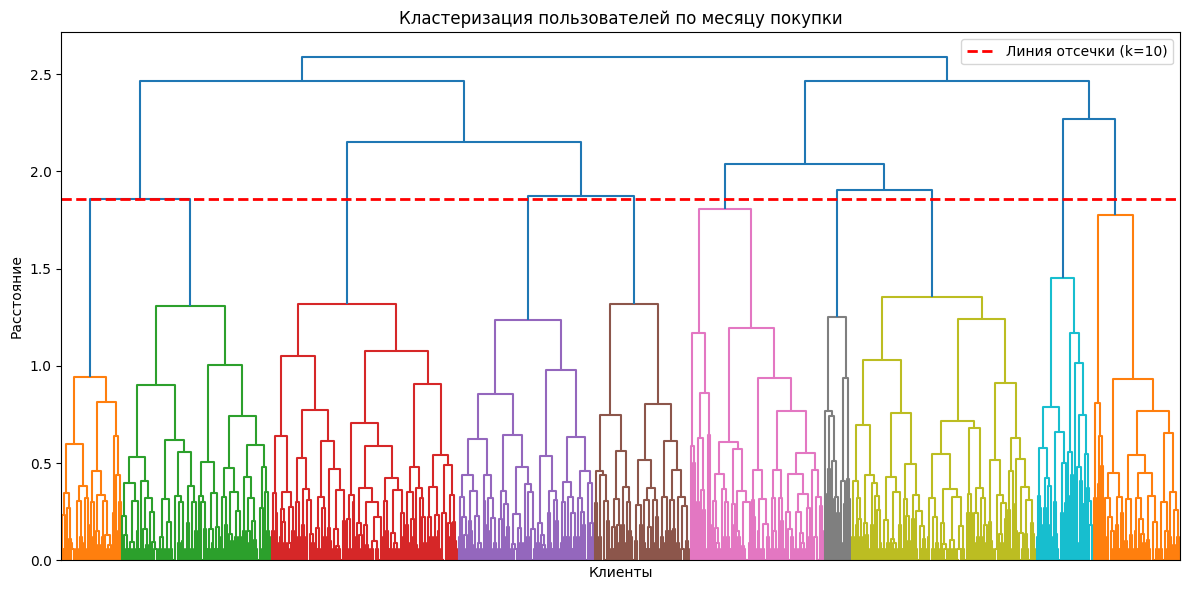

In [63]:
Z1 = linkage(X1_scaled, method=best_params1['linkage'], metric='euclidean')
plt.figure(figsize=(12, 6))

# Строим дендрограмму
dendrogram(Z1, leaf_rotation=90, leaf_font_size=8, no_labels=True)

# Рассчитываем высоту для линии отсечки (расстояние для k кластеров)
cut_height = Z1[-best_params1['n_clusters'] + 1, 2]

# Добавляем линию отсечки
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
           label=f'Линия отсечки (k={best_params1["n_clusters"]})')

plt.title(f'Кластеризация пользователей по месяцу покупки')
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100)

#### Выводы по кластеризации пользователей по полу, возрасту и месяцу покупки
По результатами кластеризации получилась следующая картина:
- Количество кластеров: 10; метод linkage: average; Silhouette Score: 0.3278;
- Самые значимые наблюдения:
  - Пользователи чётко делятся по возрасту (молодые 18-40 и зрелые 50-75) и полу, с четкой сезонностью (весна и осень);
  - Пользователи с индикатором 'Unknown' ведут себя аномально, можно лишь сказать что в оба кластера вошли молодые пользователи, делающие покупки примерно в одно время(август-сентябрь);
- Получилось следующее разбиение:
  - Молодые покупатели (18-41 год):
    - Кластер 2 (78 чел, M + Unknown): Март — мужчины покупают моду и книги;
    - Кластер 4 (85 чел, F): Август — женщины покупают моду и электронику;
    - Кластер 5 (50 чел, Unknown): Август — анонимы покупают книги и спорт;
    - Кластер 10 (54 чел, F): Февраль — женщины покупают товары для дома и моду;
  - Взрослые покупатели (32-75 лет):
    - Кластер 1 (120 чел, M + Unknown): Сентябрь — мужчины покупают электронику и моду;
    - Кластер 3 (166 чел, M): Апрель — мужчины-спортсмены;
    - Кластер 6 (167 чел, F): Сентябрь — женщины покупают электронику и товары для дома;
    - Кластер 7 (134 чел, F): Март — женщины покупают моду и книги;
    - Кластер 8 (24 чел, Unknown): Апрель — пожилые анонимы покупают спорт;
    - Кластер 9 (122 чел, M): Сентябрь — мужчины покупают спорт и книги;
- Наблюдается сезонность:
  - Февраль (зима):
    - Кластер 10: Женщины, товары для дома + мода;
  - Март (ранняя весна):
    - Кластер 2: Мужчины, мода + книги;
    - Кластер 7: Женщины, мода + книги;
  - Апрель (весна):
    - Кластер 3: Мужчины, спорт;
    - Кластер 8: Unknown (зрелые), спорт;
  - Август (лето):
    - Кластер 4: Женщины, мода + электроника;
    - Кластер 5: Unknown (молодые), книги + спорт;
  - Сентябрь (осень):
    - Кластер 1: Мужчины + Unknown, электроника + мода;
    - Кластер 6: Женщины, электроника + дом;
    - Кластер 9: Мужчины, спорт + книги.

### Кластеризация пользователей по полу, возрасту и сумме заказа

Готовим данные к кластеризации:

In [64]:
#Готовим данные к кластеризации
X = df_clusters[['age', 'gender', 'total_price']].copy()

#Кодируем столбец со значениями типа str
le_gender = LabelEncoder()
X['gender'] = le_gender.fit_transform(X['gender'])

#Масштабируем данные
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X)

Подбираем гиперпараметры для иерархического алгоритма для максимизации коэффицента силуэта:

In [65]:
#Подбор гиперпараметров через силуэтный коэффициент
best_score2 = -1
best_params2 = {'n_clusters': 3, 'linkage': 'ward'}

for linkage_method in linkage_methods:
    for n_clusters in n_clusters_range:
        try:
            agg = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage_method,
                metric='euclidean'
            )
            labels = agg.fit_predict(X2_scaled)
            score = silhouette_score(X2_scaled, labels)

            print(f"Для linkage={linkage_method:8}, n_clusters={n_clusters:2} имеем silhouette_score = {score:.4f}")

            if score > best_score2:
                best_score2 = score
                best_params2 = {
                    'n_clusters': n_clusters,
                    'linkage': linkage_method
                }
        except Exception as e:
            print(f"  linkage={linkage_method:8}, n_clusters={n_clusters}: ошибка - {str(e)[:30]}")

Для linkage=ward    , n_clusters= 2 имеем silhouette_score = 0.2469
Для linkage=ward    , n_clusters= 3 имеем silhouette_score = 0.2424
Для linkage=ward    , n_clusters= 4 имеем silhouette_score = 0.2696
Для linkage=ward    , n_clusters= 5 имеем silhouette_score = 0.3059
Для linkage=ward    , n_clusters= 6 имеем silhouette_score = 0.3236
Для linkage=ward    , n_clusters= 7 имеем silhouette_score = 0.3288
Для linkage=ward    , n_clusters= 8 имеем silhouette_score = 0.3403
Для linkage=ward    , n_clusters= 9 имеем silhouette_score = 0.3411
Для linkage=ward    , n_clusters=10 имеем silhouette_score = 0.3578
Для linkage=complete, n_clusters= 2 имеем silhouette_score = 0.2299
Для linkage=complete, n_clusters= 3 имеем silhouette_score = 0.1653
Для linkage=complete, n_clusters= 4 имеем silhouette_score = 0.1901
Для linkage=complete, n_clusters= 5 имеем silhouette_score = 0.2280
Для linkage=complete, n_clusters= 6 имеем silhouette_score = 0.2167
Для linkage=complete, n_clusters= 7 имеем silhou

Наилучшие гиперпараметры следующие:

In [66]:
#Печать лучших параметров
print(f"Лучшие параметры:")
print(f"  - Количество кластеров: {best_params2['n_clusters']}")
print(f"  - Метод linkage: {best_params2['linkage']}")
print(f"  - Silhouette Score: {best_score2:.4f}")

Лучшие параметры:
  - Количество кластеров: 10
  - Метод linkage: ward
  - Silhouette Score: 0.3578


Проводим кластеризацию с лучшими параметрами:

In [67]:
#Кластеризация с лучшими параметрами
final_clustering = AgglomerativeClustering(
    n_clusters=best_params2['n_clusters'],
    linkage=best_params2['linkage'],
    metric='euclidean'
)
df_clusters['cluster2'] = final_clustering.fit_predict(X2_scaled)

Теперь выведем ключевую информацию по получившимся кластерам:

In [68]:
#Анализ кластеров
for cluster_id in range(best_params2['n_clusters']):
    cluster_data = df_clusters[df_clusters['cluster2'] == cluster_id]

    #Возрастная статистика
    age_mean = cluster_data['age'].mean()
    age_std = cluster_data['age'].std()
    age_min = cluster_data['age'].min()
    age_max = cluster_data['age'].max()

    #Доминирующий пол
    dominant_gender = cluster_data['gender'].value_counts().index[0]

    #Месяц (средний и медианный)
    total_price_mean = cluster_data['total_price'].mean()
    total_price_median = cluster_data['total_price'].median()

    #Доминирующая категория
    gender_dist = {k: int(v) for k, v in cluster_data['gender'].value_counts().head(3).items()}
    category_dist = {k: v for k, v in cluster_data['category_name'].value_counts().head(3).items()}

    print(f"\nКЛАСТЕР {cluster_id + 1}:")
    print(f"  Размер: {len(cluster_data)} пользователей")
    print(f"  Возраст: {age_mean:.1f} ± {age_std:.1f} "
          f"(min: {age_min:.0f}, max: {age_max:.0f})")
    print(f"  Средняя цена заказа: {total_price_mean:.1f} (медиана: {total_price_median:.0f})")

    print(f"  Распределение полов: {gender_dist}")
    print(f"  Топ-3 категории по количеству покупателей: {category_dist}")


КЛАСТЕР 1:
  Размер: 83 пользователей
  Возраст: 38.7 ± 15.3 (min: 18, max: 75)
  Средняя цена заказа: 1686.2 (медиана: 1727)
  Распределение полов: {'M': 62, 'Unknown': 21}
  Топ-3 категории по количеству покупателей: {'Sports & Outdoors': 21, 'Electronics': 21, 'Books & Stationery': 20}

КЛАСТЕР 2:
  Размер: 175 пользователей
  Возраст: 31.6 ± 9.0 (min: 18, max: 50)
  Средняя цена заказа: 535.5 (медиана: 485)
  Распределение полов: {'F': 175}
  Топ-3 категории по количеству покупателей: {'Fashion': 45, 'Electronics': 37, 'Books & Stationery': 33}

КЛАСТЕР 3:
  Размер: 193 пользователей
  Возраст: 33.7 ± 9.7 (min: 18, max: 54)
  Средняя цена заказа: 442.4 (медиана: 404)
  Распределение полов: {'M': 193}
  Топ-3 категории по количеству покупателей: {'Home & Living': 43, 'Sports & Outdoors': 41, 'Books & Stationery': 38}

КЛАСТЕР 4:
  Размер: 88 пользователей
  Возраст: 56.9 ± 12.0 (min: 32, max: 75)
  Средняя цена заказа: 1146.6 (медиана: 1134)
  Распределение полов: {'M': 88}
  Топ-3

Построим дендрограмму по полученным кластерам:

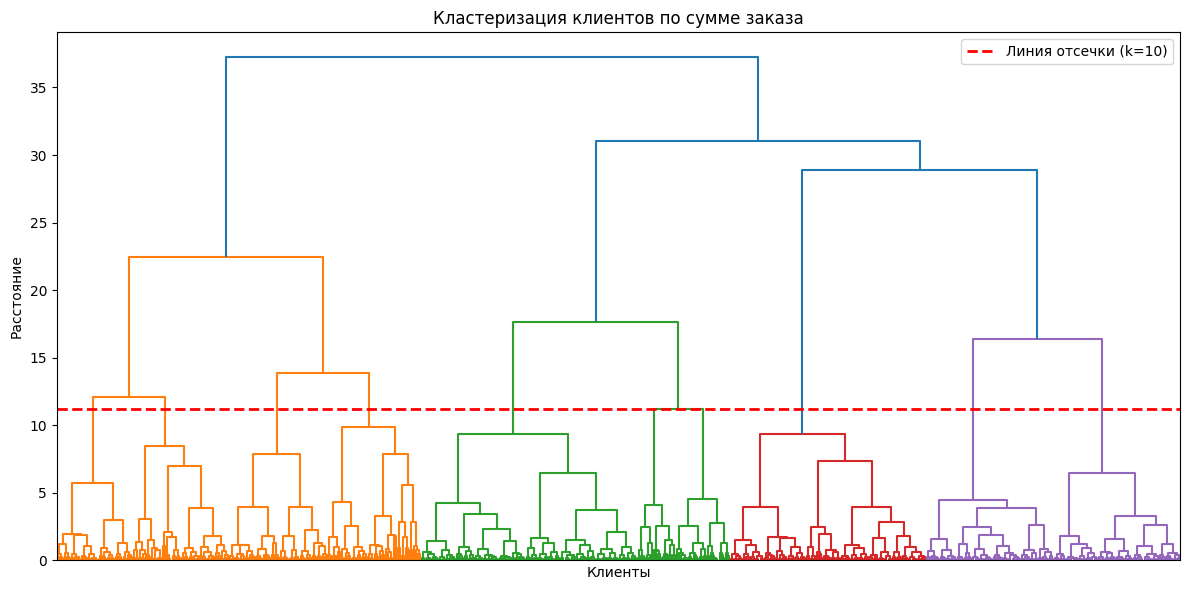

In [69]:
Z2 = linkage(X2_scaled, method=best_params2['linkage'], metric='euclidean')
plt.figure(figsize=(12, 6))

# Строим дендрограмму
dendrogram(Z2, leaf_rotation=90, leaf_font_size=8, no_labels=True)

# Рассчитываем высоту для линии отсечки (расстояние для k кластеров)
cut_height = Z2[-best_params2['n_clusters'] + 1, 2]

# Добавляем линию отсечки
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
           label=f'Линия отсечки (k={best_params2["n_clusters"]})')

plt.title(f'Кластеризация клиентов по сумме заказа')
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100)

#### Выводы по кластеризации пользователей по полу, возрасту и общей цене заказа

По результатами кластеризации получилась следующая картина:
- Количество кластеров: 10; метод linkage: ward; Silhouette Score: 0.3578;
- Самые значимые наблюдения:
  - Пользователи чётко делятся по возрасту (молодые 18-50 и зрелые 46-75) и полу, с ярко выраженными ценовыми категориями (дорогие покупки 1000-1700 и бюджетные 200-550);
  - Пользователи с индикатором 'Unknown' ведут себя в целом логично: молодые анонимы (31.6 лет) делают бюджетные покупки (около 421), а зрелые анонимы (60.8 лет) — покупки средней ценовой категории (около 543);
- Получилось следующее разбиение:
  - Молодые покупатели (18-50 лет):
    - Кластер 2 (175 чел, F): 535 — женщины покупают моду, электронику и книги;
    - Кластер 3 (193 чел, M): 442 — мужчины покупают товары для дома, спорт и книги;
    - Кластер 8 (48 чел, Unknown): 421 — молодые анонимы покупают книги, товары для дома и спорт;
  - Взрослые покупатели (46-75 лет):
    - Кластер 1 (83 чел, M + Unknown): 1686 — зрелые мужчины покупают спорт, электронику и книги;
    - Кластер 4 (88 чел, M): 1147 — мужчины покупают спорт, электронику и товары для дома;
    - Кластер 5 (85 чел, F): 1638 — женщины покупают электронику, товары для дома и моду;
    - Кластер 6 (112 чел, F): 247 — женщины-бюджетники покупают спорт, товары для дома и моду;
    - Кластер 7 (114 чел, M): 357 — мужчины-бюджетники покупают книги, электронику и моду;
    - Кластер 9 (68 чел, F): 1046 — женщины покупают электронику, моду и спорт;
    - Кластер 10 (34 чел, Unknown): 543 — зрелые анонимы покупают спорт, моду и электронику;
- Наблюдаются ценовые категории:
  - Бюджетные покупки (200-550):
    - Кластер 2 (535): Женщины (молодые), мода + электроника + книги;
    - Кластер 3 (442): Мужчины (молодые), дом + спорт + книги;
    - Кластер 6 (247): Женщины (зрелые), спорт + дом + мода;
    - Кластер 7 (357): Мужчины (зрелые), книги + электроника + мода;
    - Кластер 8 (421): Unknown (молодые), книги + дом + спорт;
    - Кластер 10 (543): Unknown (зрелые), спорт + мода + электроника;
  - Средние покупки (1000-1200):
    - Кластер 4 (1147): Мужчины (зрелые), спорт + электроника + дом;
    - Кластер 9 (1046): Женщины (зрелые), электроника + мода + спорт;
  - Дорогие покупки (1600-1700):
    - Кластер 1 (1686): Мужчины + Unknown (зрелые), спорт + электроника + книги;
    - Кластер 5 (1638): Женщины (зрелые), электроника + дом + мода.

### Кластеризация пользователей по полу, возрасту и оценкам

Готовим данные к кластеризации:

In [70]:
#Готовим данные к кластеризации
X = df_clusters[['age', 'gender', 'review_score']].copy()

#Кодируем столбец со значениями типа str
le_gender = LabelEncoder()
X['gender'] = le_gender.fit_transform(X['gender'])

#Масштабируем данные
scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X)

Подбираем гиперпараметры для иерархического алгоритма для максимизации коэффицента силуэта:

In [71]:
#Подбор гиперпараметров через силуэтный коэффициент
linkage_methods = ['ward', 'complete', 'average', 'single']
n_clusters_range = range(2, 11)
best_score3 = -1
best_params3 = {'n_clusters': 3, 'linkage': 'ward'}

for linkage_method in linkage_methods:
    for n_clusters in n_clusters_range:
        try:
            agg = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage_method,
                metric='euclidean'
            )
            labels = agg.fit_predict(X3_scaled)
            score = silhouette_score(X3_scaled, labels)

            print(f"Для linkage={linkage_method:8}, n_clusters={n_clusters:2} имеем silhouette_score = {score:.4f}")

            if score > best_score3:
                best_score3 = score
                best_params3 = {
                    'n_clusters': n_clusters,
                    'linkage': linkage_method
                }
        except Exception as e:
            print(f"  linkage={linkage_method:8}, n_clusters={n_clusters}: ошибка - {str(e)[:30]}")

Для linkage=ward    , n_clusters= 2 имеем silhouette_score = 0.3278
Для linkage=ward    , n_clusters= 3 имеем silhouette_score = 0.2862
Для linkage=ward    , n_clusters= 4 имеем silhouette_score = 0.3186
Для linkage=ward    , n_clusters= 5 имеем silhouette_score = 0.3408
Для linkage=ward    , n_clusters= 6 имеем silhouette_score = 0.3546
Для linkage=ward    , n_clusters= 7 имеем silhouette_score = 0.3644
Для linkage=ward    , n_clusters= 8 имеем silhouette_score = 0.3640
Для linkage=ward    , n_clusters= 9 имеем silhouette_score = 0.3877
Для linkage=ward    , n_clusters=10 имеем silhouette_score = 0.3879
Для linkage=complete, n_clusters= 2 имеем silhouette_score = 0.3332
Для linkage=complete, n_clusters= 3 имеем silhouette_score = 0.2900
Для linkage=complete, n_clusters= 4 имеем silhouette_score = 0.2680
Для linkage=complete, n_clusters= 5 имеем silhouette_score = 0.2874
Для linkage=complete, n_clusters= 6 имеем silhouette_score = 0.2734
Для linkage=complete, n_clusters= 7 имеем silhou

Наилучшие гиперпараметры следующие:

In [72]:
#Печать лучших параметров
print(f"Лучшие параметры:")
print(f"  - Количество кластеров: {best_params3['n_clusters']}")
print(f"  - Метод linkage: {best_params3['linkage']}")
print(f"  - Silhouette Score: {best_score3:.4f}")

Лучшие параметры:
  - Количество кластеров: 10
  - Метод linkage: average
  - Silhouette Score: 0.3901


Проводим кластеризацию с лучшими параметрами:

In [73]:
#Кластеризация с лучшими параметрами
final_clustering = AgglomerativeClustering(
    n_clusters=best_params3['n_clusters'],
    linkage=best_params3['linkage'],
    metric='euclidean'
)
df_clusters['cluster3'] = final_clustering.fit_predict(X3_scaled)

Теперь выведем ключевую информацию по получившимся кластерам:

In [74]:
#Анализ кластеров
for cluster_id in range(best_params3['n_clusters']):
    cluster_data = df_clusters[df_clusters['cluster3'] == cluster_id]

    #Возрастная статистика
    age_mean = cluster_data['age'].mean()
    age_std = cluster_data['age'].std()
    age_min = cluster_data['age'].min()
    age_max = cluster_data['age'].max()

    #Доминирующий пол
    dominant_gender = cluster_data['gender'].value_counts().index[0]

    #Месяц (средний и медианный)
    review_score_mean = cluster_data['review_score'].mean()
    review_score_median = cluster_data['review_score'].median()

    #Доминирующая категория
    gender_dist = {k: int(v) for k, v in cluster_data['gender'].value_counts().head(3).items()}
    category_dist = {k: v for k, v in cluster_data['category_name'].value_counts().head(3).items()}

    print(f"\nКЛАСТЕР {cluster_id + 1}:")
    print(f"  Размер: {len(cluster_data)} пользователей")
    print(f"  Возраст: {age_mean:.1f} ± {age_std:.1f} "
          f"(min: {age_min:.0f}, max: {age_max:.0f})")
    print(f"  Средняя оценка: {review_score_mean:.1f} (медиана: {review_score_median:.0f})")

    print(f"  Распределение полов: {gender_dist}")
    print(f"  Топ-3 категории по количеству покупателей: {category_dist}")


КЛАСТЕР 1:
  Размер: 52 пользователей
  Возраст: 58.9 ± 8.6 (min: 42, max: 75)
  Средняя оценка: 2.2 (медиана: 2)
  Распределение полов: {'M': 50, 'Unknown': 2}
  Топ-3 категории по количеству покупателей: {'Home & Living': 11, 'Sports & Outdoors': 11, 'Fashion': 11}

КЛАСТЕР 2:
  Размер: 55 пользователей
  Возраст: 48.4 ± 14.6 (min: 20, max: 75)
  Средняя оценка: 1.4 (медиана: 1)
  Распределение полов: {'F': 55}
  Топ-3 категории по количеству покупателей: {'Home & Living': 14, 'Electronics': 12, 'Fashion': 12}

КЛАСТЕР 3:
  Размер: 39 пользователей
  Возраст: 62.1 ± 8.3 (min: 48, max: 75)
  Средняя оценка: 4.6 (медиана: 5)
  Распределение полов: {'Unknown': 39}
  Топ-3 категории по количеству покупателей: {'Sports & Outdoors': 15, 'Electronics': 8, 'Fashion': 6}

КЛАСТЕР 4:
  Размер: 16 пользователей
  Возраст: 34.9 ± 11.9 (min: 20, max: 59)
  Средняя оценка: 2.8 (медиана: 3)
  Распределение полов: {'Unknown': 16}
  Топ-3 категории по количеству покупателей: {'Electronics': 4, 'Home

Построим дендрограмму по полученным кластерам:

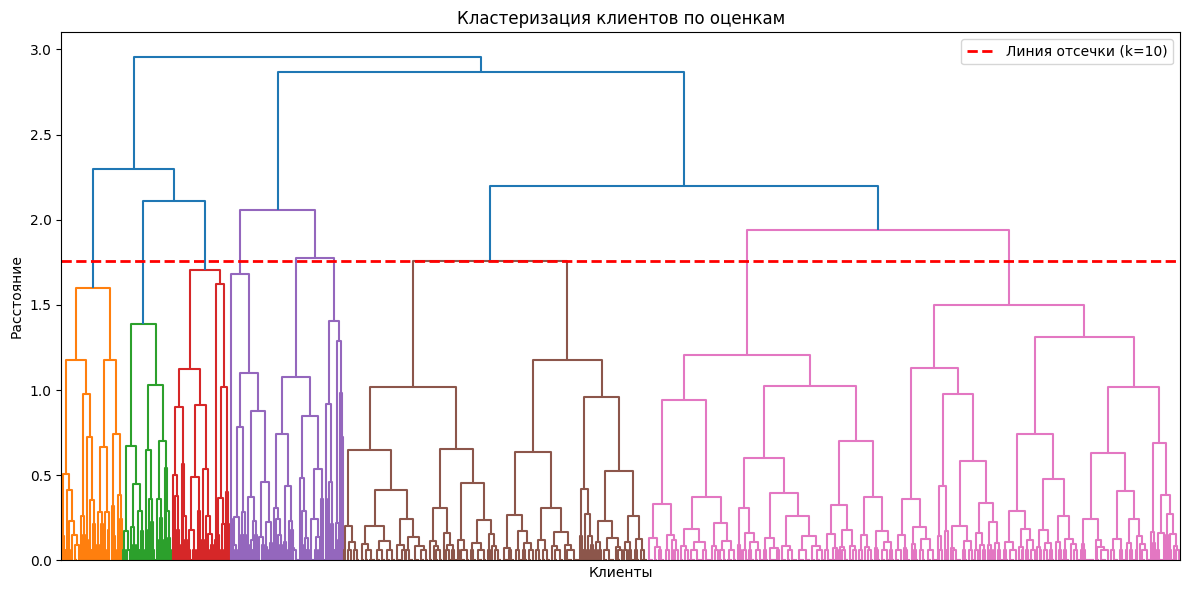

In [75]:
Z3 = linkage(X3_scaled, method=best_params3['linkage'], metric='euclidean')
plt.figure(figsize=(12, 6))

# Строим дендрограмму
dendrogram(Z3, leaf_rotation=90, leaf_font_size=8, no_labels=True)

# Рассчитываем высоту для линии отсечки (расстояние для k кластеров)
cut_height = Z3[-best_params3['n_clusters'] + 1, 2]

# Добавляем линию отсечки
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
           label=f'Линия отсечки (k={best_params3["n_clusters"]})')

plt.title(f'Кластеризация клиентов по оценкам')
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100)

#### Выводы по кластеризации пользователей по полу, возрасту и оценке заказа

По результатами кластеризации получилась следующая картина:
- Количество кластеров: 10; метод linkage: average; Silhouette Score: 0.3901;
- Самые значимые наблюдения:
  - Пользователи чётко делятся по возрасту (молодые 18-58 и зрелые 56-75) и полу, с ярко выраженными оценочными категориями (низкие оценки 1-3 vs высокие оценки 4-5);
  - Пользователи с индикатором 'Unknown' ведут себя аномально: есть как молодые анонимы с низкими оценками (2.8), так и зрелые анонимы с очень высокими оценками (4.6);
- Получилось следующее разбиение:
  - Молодые покупатели (18-58 лет):
    - Кластер 4 (16 чел, Unknown): 2.8 — молодые анонимы покупают электронику, товары для дома и моду;
    - Кластер 5 (255 чел, F): 4.3 — женщины покупают моду, электронику и книги;
    - Кластер 6 (44 чел, M): 2.2 — мужчины покупают книги, электронику и спорт;
    - Кластер 8 (221 чел, M): 4.6 — мужчины покупают спорт, товары для дома и моду;
    - Кластер 9 (46 чел, Unknown): 4.5 — молодые анонимы покупают книги, товары для дома и спорт;
  - Взрослые покупатели (56-75 лет):
    - Кластер 1 (52 чел, M + Unknown): 2.2 — зрелые мужчины покупают товары для дома, спорт и моду;
    - Кластер 2 (55 чел, F): 1.4 — женщины-критики покупают товары для дома, электронику и моду;
    - Кластер 3 (39 чел, Unknown): 4.6 — зрелые анонимы покупают спорт, электронику и моду;
    - Кластер 7 (130 чел, F): 4.4 — женщины покупают спорт, моду и электронику;
    - Кластер 10 (142 чел, M): 4.5 — мужчины покупают электронику, книги и спорт;
- Наблюдаются оценочные категории:
  - Низкие оценки (1-3):
    - Кластер 1 (2.2): Мужчины + Unknown (зрелые), дом + спорт + мода;
    - Кластер 2 (1.4): Женщины (зрелые), дом + электроника + мода;
    - Кластер 4 (2.8): Unknown (молодые), электроника + дом + мода;
    - Кластер 6 (2.2): Мужчины (молодые), книги + электроника + спорт;
  - Высокие оценки (4-5):
    - Кластер 3 (4.6): Unknown (зрелые), спорт + электроника + мода;
    - Кластер 5 (4.3): Женщины (молодые), мода + электроника + книги;
    - Кластер 7 (4.4): Женщины (зрелые), спорт + мода + электроника;
    - Кластер 8 (4.6): Мужчины (молодые), спорт + дом + мода;
    - Кластер 9 (4.5): Unknown (молодые), книги + дом + спорт;
    - Кластер 10 (4.5): Мужчины (зрелые), электроника + книги + спорт.

## Итоговые выводы по проекту

### EDA:
1) **Клиенты и заказы:**
 - Клиенты в целом равномерно распределены по возрасту за исключением двух возрастных групп: 15-19 и 75-79. Лидируют по количеству клиентов группы 60-64(104 человека) и 25-29(94 человека);

 - Клиенты равномерно распределены по полу;

 - В целом заказы распределены по дням недели равномерно, но в будни их больше;

 - Больше всего заказов в пятницу (150), меньше всего в воскресенье (130);

 - Для возрастной группы 18-30 самыми популярными днями были четверг (16.4%), вторник (15.5%) и воскресенье (15.5%);

 - Для возрастной группы 31-45 самыми популярными днями были четверг (17.0%), понедельник (15.4%) и пятница (15.1%);

 - Для возрастной группы 46-60 самыми популярными днями были среда (16.8%) и пятница (16.0%);

 - Для возрастной группы 60+ самыми популярными днями были вторник (19.2%) и суббота (16.2%);

 - Наибольшее количество заказов было сделано в декабре и январе, в мае и в период с июля по сентябрь;

 - Для группы 31-45 самыми популярными днями были четверг (17.0%), понедельник (15.4%) и пятница (15.1%);

 - Для группы 46-60 самыми популярными днями были среда (16.8%) и пятница (16.0%);

 - Для группы 60+ самыми популярными днями были вторник (19.2%) и суббота (16.2%).

2) **Выручка:**
 - Смартфоны лидируют и по выручке, и по количеству проданного товара, также следует отметить маты для йоги и футбольные мячи;

 - Товары из категории ***"Электроника"*** заняли 5 позиций в топе по выручке (смартфоны, планшеты, ноутбуки, умные часы и наушники), из категории ***"Спорт"*** - 2 позиции (маты для йоги и футбольные мячи), из категории ***"Книги"*** - 1 позиция (тетради), из категории ***"Вещи для дома"*** - 1 позиция (вазы), из категории ***"Одежда"*** - 1 позиция (футболки);

 - Товары из категории ***"Электроника"*** заняли 3 позиций в топе по количеству (смартфоны, ноутбуки и наушники), из категории ***"Спорт"*** - 3 позиции (маты для йоги, футбольные мячи и  ботинки для бега), из категории ***"Книги"*** - 2 позиции (тетради и ластики), из категории ***"Одежда"*** - 1 позиция (футболки), из категории ***"Вещи для дома"*** - 1 позиция (вазы);

 - Лидером является категория "Электроника", на втором месте - "Спорт", на третьем - "Книги";

 - В городах с самой большой выручкой средний чек меньше, но там делают больше покупок;

 - Среди топ-10 городов по выручке Port Melissaborough лидирует в категории "Вещи для дома", Patriciaville - в категории "Спорт", Johnsonborough - в категории "Одежда", East David - в категории "Электроника", East William - в категории "Книги";

 - Больше всего выручки в этих городах было получено от категории "Вещи для дома", меньше всего - от категории "Электроника";

 - На 5 городов с самой большой выручкой приходится более половина от общей выручки на платформе;

 - В целом у всех трёх способов оплаты наблюдается схожая ситуация с суммами заказов: медианы, 1-ая и 3-ая квартили близки по своим значениям;

- Для заказов, оплаченных банковскими переводами верхняя граница ниже чем у двух других способов оплаты, и из-за этого чуть больше значений-выбросов;

- Оплата наличными встречается немного чаще, но в целом все три способа оплаты одинаково популярны;

- Средний чек у заказов, оплаченных кредитными картами, чуть выше, чем  у остальных двух способов, но они не сильно различаются.

3) **Оценки:**

- Средние оценки для способов оплаты практически не отличаются;

- Более 75% всех заказов имеют хорошую оценку 4 или 5 (781 заказ), количество заказов с плохим оценками 1 и 2 сильно меньше (110 заказов);

- Для всех 5 оценок нет значений-выбросов среди цен;

- У оценок "1", "4", "5"  различаются квартили, межквартильный размах, верхние и нижние границы, но при у всех трёх медиана совпадает со средним;

- У оценки "2"  медиана меньше среднего, что говорит о наличии смещения цен в большую сторону в этой группе;

- У оценки "3" самый большой межквартильным размахом, а также медиана больше среднего, что говорит о наличии смещения цен в меньшую сторону в этой группе;

- У категории товаров "Спорт" средняя оценка заметно выше, чем у других, остальные 4 категории между собой практически не различаются;

- У категории "Вещи для дома" самая высокая доля низких оценок(13.1%), на втором месте категория "Спорт"(11.8%), остальные 3 категории между собой практически не различаются.

### Регрессия:

1) **Матрица корреляций:**
- В данных практически нет корреляций между признаками (максимальное значение в таблице - 0.09 между признакамми 'month' и 'quantity'), из чего был сделан вывод, что на данном датасете не получится построить точную модель.

2) **Регрессия:**
- Модель получилась слабая, как и предполагалось на этапе изучения корреляций;
- На обучающей выборке R² = 0.0142 и на тестовой R² = -0.0248;
- Метрики ошибки на тестовой выборке следующие **MAE** = 1.19, **RMSE** = 1.39, **MAPE** = 53.11%.

### Кластеризация:

1) **Кластеризация пользователей по полу, возрасту и месяцу покупки:**
- Количество кластеров: 10; метод linkage: average; Silhouette Score: 0.3278;
- Самые значимые наблюдения:
  - Пользователи чётко делятся по возрасту (молодые 18-40 и зрелые 50-75) и полу, с четкой сезонностью (весна и осень);
  - Пользователи с индикатором 'Unknown' ведут себя аномально, можно лишь сказать что в оба кластера вошли молодые пользователи, делающие покупки примерно в одно время(август-сентябрь);
- Получилось следующее разбиение:
  - Молодые покупатели (18-41 год):
    - Кластер 2 (78 чел, M + Unknown): Март — мужчины покупают моду и книги;
    - Кластер 4 (85 чел, F): Август — женщины покупают моду и электронику;
    - Кластер 5 (50 чел, Unknown): Август — анонимы покупают книги и спорт;
    - Кластер 10 (54 чел, F): Февраль — женщины покупают товары для дома и моду;
  - Взрослые покупатели (32-75 лет):
    - Кластер 1 (120 чел, M + Unknown): Сентябрь — мужчины покупают электронику и моду;
    - Кластер 3 (166 чел, M): Апрель — мужчины-спортсмены;
    - Кластер 6 (167 чел, F): Сентябрь — женщины покупают электронику и товары для дома;
    - Кластер 7 (134 чел, F): Март — женщины покупают моду и книги;
    - Кластер 8 (24 чел, Unknown): Апрель — пожилые анонимы покупают спорт;
    - Кластер 9 (122 чел, M): Сентябрь — мужчины покупают спорт и книги;
- Наблюдается сезонность:
  - Февраль (зима):
    - Кластер 10: Женщины, товары для дома + мода;
  - Март (ранняя весна):
    - Кластер 2: Мужчины, мода + книги;
    - Кластер 7: Женщины, мода + книги;
  - Апрель (весна):
    - Кластер 3: Мужчины, спорт;
    - Кластер 8: Unknown (зрелые), спорт;
  - Август (лето):
    - Кластер 4: Женщины, мода + электроника;
    - Кластер 5: Unknown (молодые), книги + спорт;
  - Сентябрь (осень):
    - Кластер 1: Мужчины + Unknown, электроника + мода;
    - Кластер 6: Женщины, электроника + дом;
    - Кластер 9: Мужчины, спорт + книги.

2) **Кластеризация пользователей по полу, возрасту и общей цене заказа:**
- Количество кластеров: 10; метод linkage: ward; Silhouette Score: 0.3578;
- Самые значимые наблюдения:
  - Пользователи чётко делятся по возрасту (молодые 18-50 и зрелые 46-75) и полу, с ярко выраженными ценовыми категориями (дорогие покупки 1000-1700 и бюджетные 200-550);
  - Пользователи с индикатором 'Unknown' ведут себя в целом логично: молодые анонимы (31.6 лет) делают бюджетные покупки (около 421), а зрелые анонимы (60.8 лет) — покупки средней ценовой категории (около 543);
- Получилось следующее разбиение:
  - Молодые покупатели (18-50 лет):
    - Кластер 2 (175 чел, F): 535 — женщины покупают моду, электронику и книги;
    - Кластер 3 (193 чел, M): 442 — мужчины покупают товары для дома, спорт и книги;
    - Кластер 8 (48 чел, Unknown): 421 — молодые анонимы покупают книги, товары для дома и спорт;
  - Взрослые покупатели (46-75 лет):
    - Кластер 1 (83 чел, M + Unknown): 1686 — зрелые мужчины покупают спорт, электронику и книги;
    - Кластер 4 (88 чел, M): 1147 — мужчины покупают спорт, электронику и товары для дома;
    - Кластер 5 (85 чел, F): 1638 — женщины покупают электронику, товары для дома и моду;
    - Кластер 6 (112 чел, F): 247 — женщины-бюджетники покупают спорт, товары для дома и моду;
    - Кластер 7 (114 чел, M): 357 — мужчины-бюджетники покупают книги, электронику и моду;
    - Кластер 9 (68 чел, F): 1046 — женщины покупают электронику, моду и спорт;
    - Кластер 10 (34 чел, Unknown): 543 — зрелые анонимы покупают спорт, моду и электронику;
- Наблюдаются ценовые категории:
  - Бюджетные покупки (200-550):
    - Кластер 2 (535): Женщины (молодые), мода + электроника + книги;
    - Кластер 3 (442): Мужчины (молодые), дом + спорт + книги;
    - Кластер 6 (247): Женщины (зрелые), спорт + дом + мода;
    - Кластер 7 (357): Мужчины (зрелые), книги + электроника + мода;
    - Кластер 8 (421): Unknown (молодые), книги + дом + спорт;
    - Кластер 10 (543): Unknown (зрелые), спорт + мода + электроника;
  - Средние покупки (1000-1200):
    - Кластер 4 (1147): Мужчины (зрелые), спорт + электроника + дом;
    - Кластер 9 (1046): Женщины (зрелые), электроника + мода + спорт;
  - Дорогие покупки (1600-1700):
    - Кластер 1 (1686): Мужчины + Unknown (зрелые), спорт + электроника + книги;
    - Кластер 5 (1638): Женщины (зрелые), электроника + дом + мода.

3) **Кластеризация пользователей по полу, возрасту и оценке заказа:**
- Количество кластеров: 10; метод linkage: average; Silhouette Score: 0.3901;
- Самые значимые наблюдения:
  - Пользователи чётко делятся по возрасту (молодые 18-58 и зрелые 56-75) и полу, с ярко выраженными оценочными категориями (низкие оценки 1-3 vs высокие оценки 4-5);
  - Пользователи с индикатором 'Unknown' ведут себя аномально: есть как молодые анонимы с низкими оценками (2.8), так и зрелые анонимы с очень высокими оценками (4.6);
- Получилось следующее разбиение:
  - Молодые покупатели (18-58 лет):
    - Кластер 4 (16 чел, Unknown): 2.8 — молодые анонимы покупают электронику, товары для дома и моду;
    - Кластер 5 (255 чел, F): 4.3 — женщины покупают моду, электронику и книги;
    - Кластер 6 (44 чел, M): 2.2 — мужчины покупают книги, электронику и спорт;
    - Кластер 8 (221 чел, M): 4.6 — мужчины покупают спорт, товары для дома и моду;
    - Кластер 9 (46 чел, Unknown): 4.5 — молодые анонимы покупают книги, товары для дома и спорт;
  - Взрослые покупатели (56-75 лет):
    - Кластер 1 (52 чел, M + Unknown): 2.2 — зрелые мужчины покупают товары для дома, спорт и моду;
    - Кластер 2 (55 чел, F): 1.4 — женщины-критики покупают товары для дома, электронику и моду;
    - Кластер 3 (39 чел, Unknown): 4.6 — зрелые анонимы покупают спорт, электронику и моду;
    - Кластер 7 (130 чел, F): 4.4 — женщины покупают спорт, моду и электронику;
    - Кластер 10 (142 чел, M): 4.5 — мужчины покупают электронику, книги и спорт;
- Наблюдаются оценочные категории:
  - Низкие оценки (1-3):
    - Кластер 1 (2.2): Мужчины + Unknown (зрелые), дом + спорт + мода;
    - Кластер 2 (1.4): Женщины (зрелые), дом + электроника + мода;
    - Кластер 4 (2.8): Unknown (молодые), электроника + дом + мода;
    - Кластер 6 (2.2): Мужчины (молодые), книги + электроника + спорт;
  - Высокие оценки (4-5):
    - Кластер 3 (4.6): Unknown (зрелые), спорт + электроника + мода;
    - Кластер 5 (4.3): Женщины (молодые), мода + электроника + книги;
    - Кластер 7 (4.4): Женщины (зрелые), спорт + мода + электроника;
    - Кластер 8 (4.6): Мужчины (молодые), спорт + дом + мода;
    - Кластер 9 (4.5): Unknown (молодые), книги + дом + спорт;
    - Кластер 10 (4.5): Мужчины (зрелые), электроника + книги + спорт.